## Télécharger les données

In [ ]:
#!pip install huggingface_hub

In [ ]:
#from huggingface_hub import HfApi, snapshot_download
#import os

# Define repository ID and local paths
#repo_id = "LYM619/Face4FairShifts"
#local_repo_path = "./Face4FairShifts_local"
#unzipped_data_path = "./Face4FairShifts_unzipped"



In [4]:
import pandas as pd
a_attr = pd.read_json("../Anno/a_attr.json", lines=True)
c_attr = pd.read_json("../Anno/c_attr.json", lines=True)
p_attr = pd.read_json("../Anno/p_attr.json", lines=True)
s_attr = pd.read_json("../Anno/s_attr.json", lines=True)

In [12]:
import json

with open("../croissant/metadata.json") as f:
    meta = json.load(f)

attr_mapping = {}
for field in meta["schema"]["fields"]:
    if field["type"] == "integer":
        desc = field["description"]
        parts = [p.strip() for p in desc.split(",")]
        mapping = {}
        for p in parts:
            val, label = p.split("=")
            mapping[int(val.strip())] = label.strip()
        attr_mapping[field["name"]] = mapping


print(attr_mapping)
print(a_attr["gender"].map(mapping))

{'gender': {1: 'male', 2: 'female'}, 'Asian': {1: 'yes', 2: 'no'}, 'Black': {1: 'yes', 2: 'no'}, 'Others': {1: 'yes', 2: 'no'}, 'teenager': {1: 'yes', 2: 'no'}, 'middle': {1: 'yes', 2: 'no'}, 'elderly': {1: 'yes', 2: 'no'}, 'wrinkles': {1: 'yes', 2: 'no'}, 'sideburns': {1: 'yes', 2: 'no'}, 'moustache/goatee': {1: 'yes', 2: 'no'}, 'beard': {1: 'yes', 2: 'no'}, 'clear_glasses': {1: 'yes', 2: 'no'}, 'sunglasses': {1: 'yes', 2: 'no'}, 'glasses': {1: 'yes', 2: 'no'}, 'open_eyes': {1: 'yes', 2: 'no'}, 'eyebrows': {1: 'yes', 2: 'no'}, 'open_mouth': {1: 'yes', 2: 'no'}, 'show_teeth': {1: 'yes', 2: 'no'}, 'smile_with_closed_lips': {1: 'yes', 2: 'no'}, 'smile_with_open_lips': {1: 'yes', 2: 'no'}, 'show_ears': {1: 'yes', 2: 'no'}, 'earring': {1: 'yes', 2: 'no'}, 'pointed_nose': {1: 'yes', 2: 'no'}, 'round_nose': {1: 'yes', 2: 'no'}, 'pointed_chin': {1: 'yes', 2: 'no'}, 'round_chin': {1: 'yes', 2: 'no'}, 'bald': {1: 'yes', 2: 'no'}, 'sparse_hair': {1: 'yes', 2: 'no'}, 'short_hair': {1: 'yes', 2: '

In [8]:
from PIL import Image

img = Image.open('../Data/Photo/p00001.jpg')
img.show()

### Liste de tous les attributs de p_attr

In [16]:
print(p_attr.columns.tolist())

['ID', 'gender', 'Asian', 'Black', 'Others', 'teenager', 'middle', 'elderly', 'wrinkles', 'sideburns', 'moustache/goatee', 'beard', 'clear_glasses', 'sunglasses', 'glasses', 'open_eyes', 'eyebrows', 'open_mouth', 'show_teeth', 'smile_with_closed_lips', 'smile_with_open_lips', 'show_ears', 'earring', 'pointed_nose', 'round_nose', 'pointed_chin', 'round_chin', 'bald', 'sparse_hair', 'short_hair', 'long_hair', 'straight_hair', 'curly_hair', 'bangs', 'one_braid', '≥2_braids', 'braids', 'hair_wear', 'hat', 'Attractive']


## Matrice de confusion

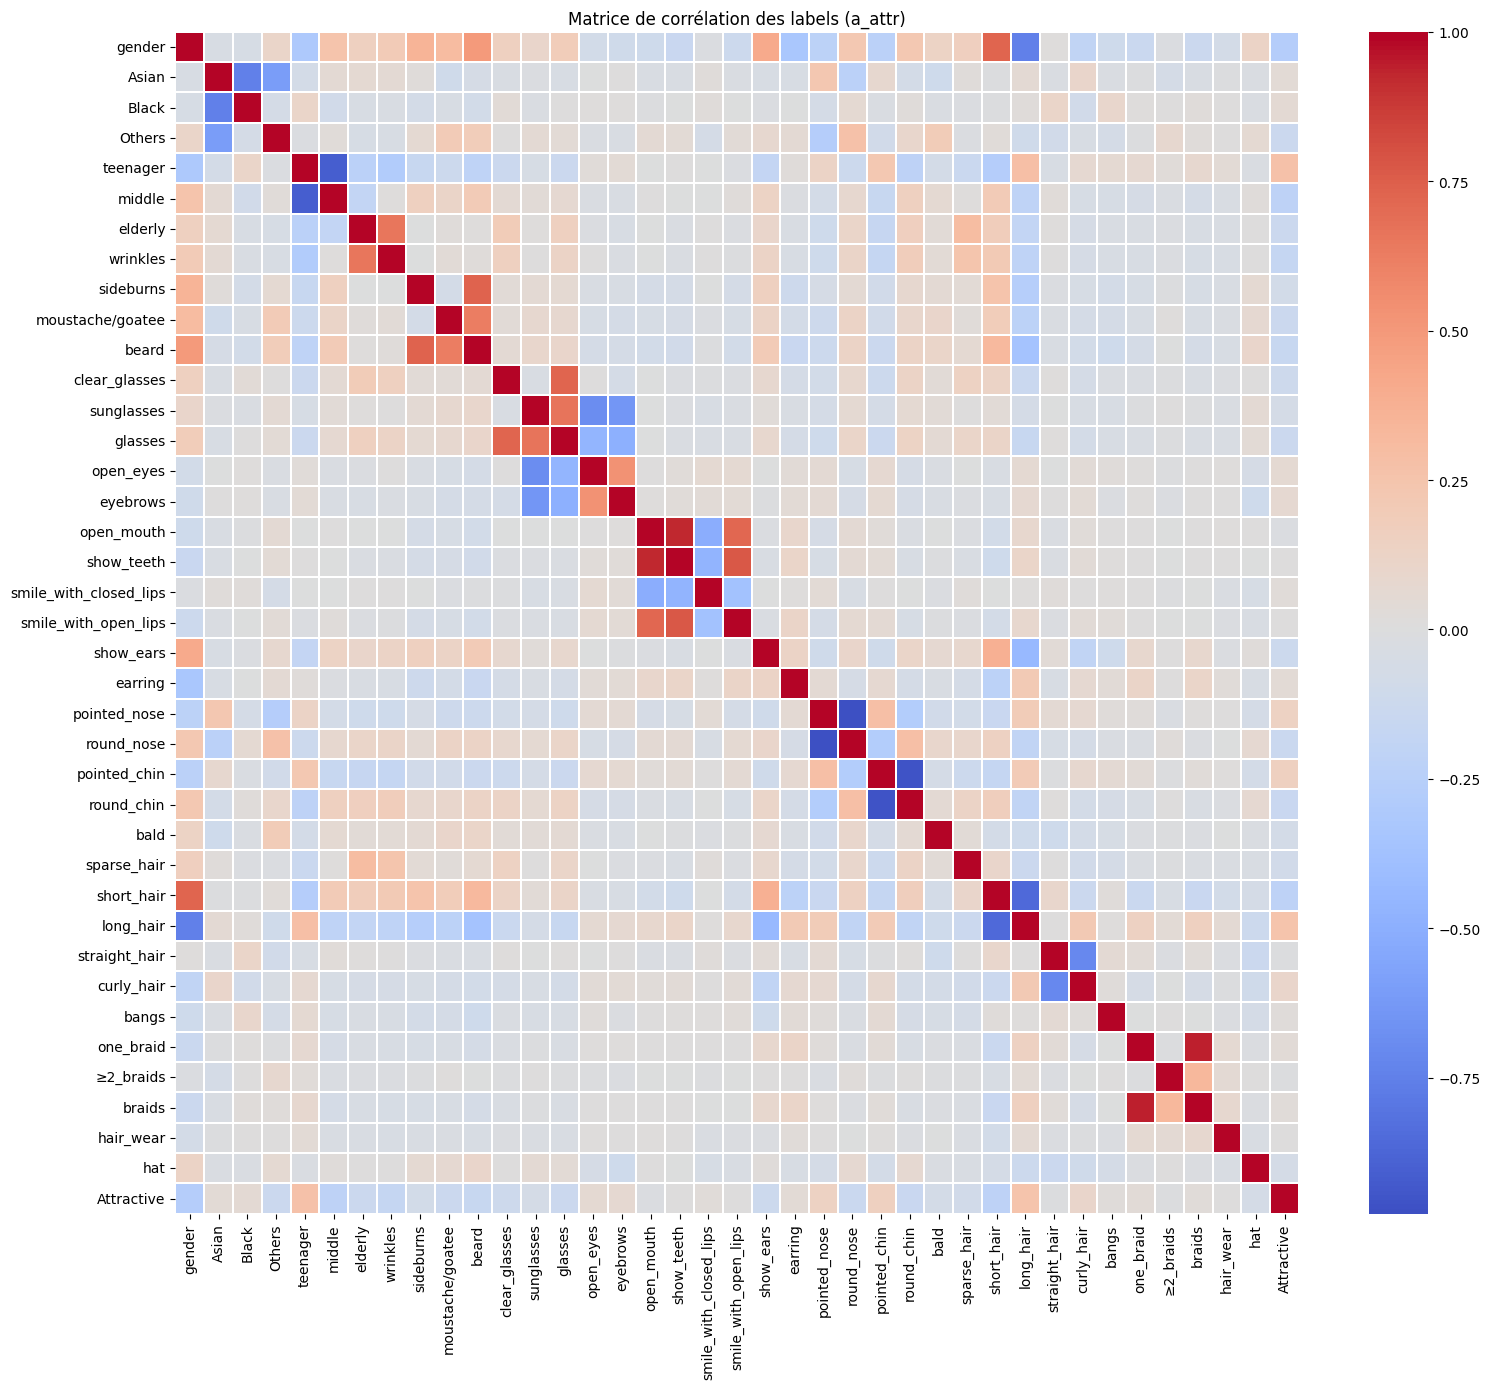

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Binariser (1 -> 1, 2 -> 0)
labels = p_attr.drop(columns=["ID"])
labels_bin = (labels == 1).astype(int)

# Matrice de corrélation
corr = labels_bin.corr()

# Visualisation
plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Matrice de corrélation des labels (a_attr)")
plt.tight_layout()
plt.show()

### Observations :
- Le genre semble être corrélé: barbe, au fait de voir les oreilles (cheveux), cheveux court et inversement aux cheveux longs.
- L'ethnie est très décorrélée des autres ethnies + nez pointu (asiatique)
- ethnique autre: nez rond

...

## 1. Définition de X, Y et S

In [ ]:
# X est la feature il est composé des labels de sourire et de longueur de cheveux :
X = p_attr[['smile_with_closed_lips', 'smile_with_open_lips', 'short_hair', 'long_hair']]
# Y est la cible à prédire, le genre :
Y = p_attr['gender']
# Attribut sensible : Asian/ Black/ Others.
# On peut également prendre la tranche d'âge
S = p_attr[['Asian', 'Black', 'Others']]

# On binarise les labels : 1 vaut 1 et 2 vaut 0
labels = p_attr.drop(columns=["ID"])
labels_bin = (labels == 1).astype(int)

# Construction définitive
X = labels_bin[['smile_with_closed_lips', 'smile_with_open_lips', 'short_hair', 'long_hair']]
Y = labels_bin['gender']
S = labels_bin[['Asian', 'Black', 'Others']]

## 2. Etude des distributions de X, Y et S

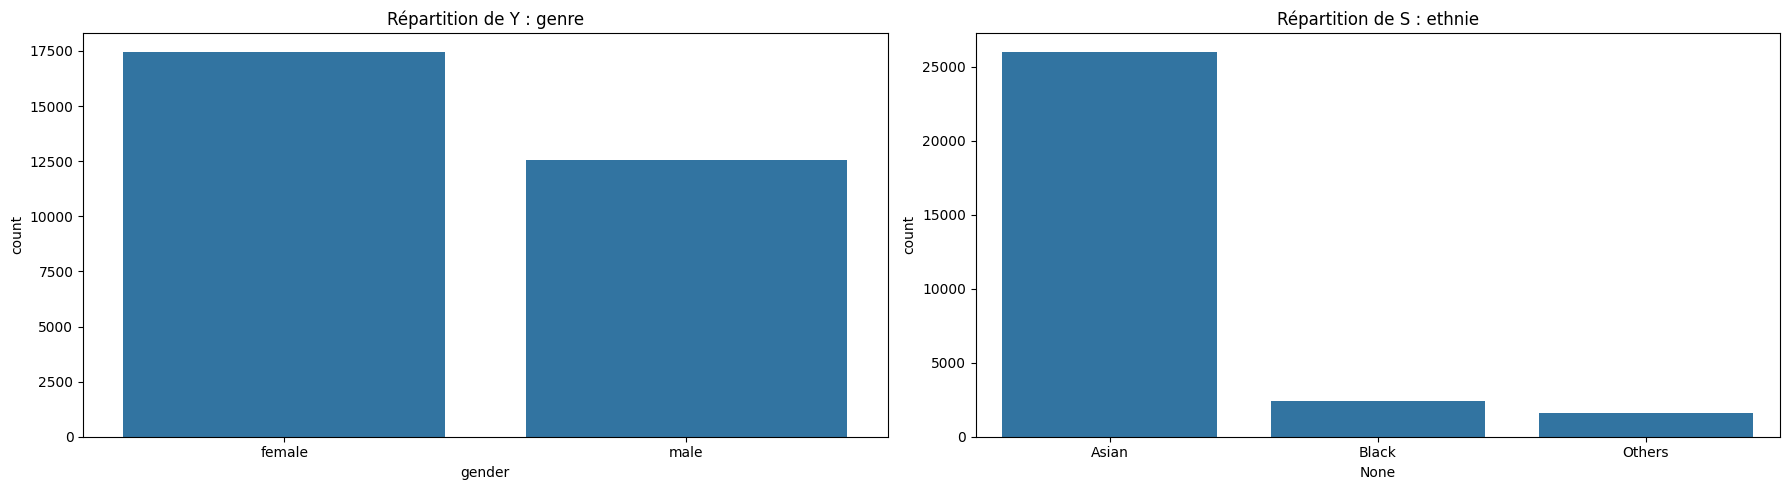

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Mappings pour ne pas visualiser les valeurs binaires
gender_map = {1: 'male', 2: 'female'}
ethnicity_map = {1: 'yes', 2: 'no'}

# Y
Y_named = p_attr['gender'].map(gender_map)
sns.countplot(x=Y_named, ax=axes[0])
axes[0].set_title('Répartition de Y : genre')

# S : création d'une colonne "ethnie" pour la visualisation
def get_ethnicity(row):
    if row['Asian'] == 1: return 'Asian'
    if row['Black'] == 1: return 'Black'
    if row['Others'] == 1: return 'Others'
    return 'Unknown'

S_named = p_attr.apply(get_ethnicity, axis=1)
sns.countplot(x=S_named, ax=axes[1])
axes[1].set_title('Répartition de S : ethnie')

plt.tight_layout()
plt.show()

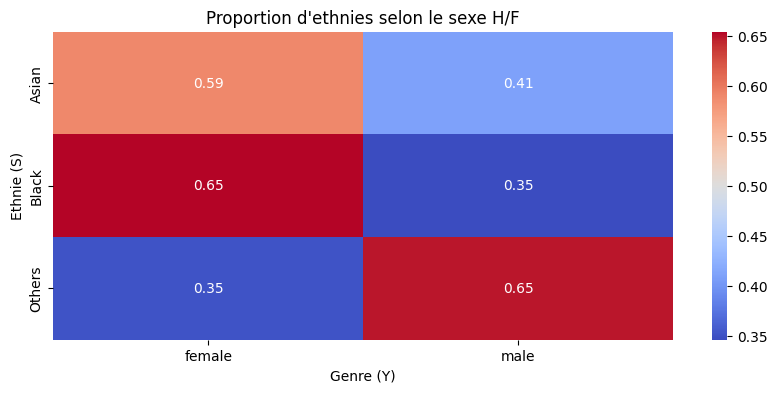

In [44]:
# Visualisation de YxS
# Permet de voir la répartition des ethnies selon les sexes

df = pd.DataFrame({'S': S_named, 'Y': Y_named})

contingency_table = df.groupby(['S', 'Y']).size().unstack(fill_value=0)
contingency_table_norm = contingency_table.div(contingency_table.sum(axis=1), axis=0)

plt.figure(figsize=(10, 4))
sns.heatmap(contingency_table_norm, cmap='coolwarm', annot=True, fmt=".2f", center=0.5)
plt.xlabel("Genre (Y)")
plt.ylabel("Ethnie (S)")
plt.title("Proportion d'ethnies selon le sexe H/F")
plt.show()

### Observations :
La répartition des ethnies n'est pas du tout équilibrée selon le genre.

## Fonctions SP et EO _reprises du tp_

In [45]:
import numpy as np

In [47]:
## Parité statistique
def compute_sp(y_pred, sensitive_attr):
    classes = np.unique(y_pred)
    groups = np.unique(sensitive_attr)
    
    sp_per_class = {}
    for c in classes:
        probs = {}  # Proba de prédire la classe c pour chaque groupe
        for g in groups:
            mask = (sensitive_attr == g)
            probs[g] = np.mean(y_pred[mask] == c)  # P(ŷ = c | groupe = g)
            
            # Mesure de disparité : max des différences entre groupes 
        sp_per_class[c] = max(probs.values()) - min(probs.values())
    sp = np.mean(list(sp_per_class.values()))    
    return sp_per_class, sp

_Cette fonction permet de déterminer si le modèle est équitable. Il étudie ça si la probabilité d'être prédit dans une classe c est la même pour tous les groupes g (ce qui permet aussi de se rendre compte si les groupes sont équilibrées = même taille/ répartition)._

In [ ]:
# Equalized Odds
def compute_eo(y_true, y_pred, sensitive_attr):
    classes = np.unique(y_true)
    groups = np.unique(sensitive_attr)
    
    eo_per_class = {}
    for c in classes:
        tprs = {}  # True Positive Rate pour chaque groupe
        for g in groups:
            mask = (sensitive_attr == g) & (y_true == c)  # Individus du groupe g dont le vrai label est c
            if mask.sum() == 0:
                tprs[g] = 0
            else:
                tprs[g] = np.mean(y_pred[mask] == c)  # P(ŷ = c | Y = c, S = g)
        
        eo_per_class[c] = max(tprs.values()) - min(tprs.values())
    
    eo = np.mean(list(eo_per_class.values()))
    return eo_per_class, eo

_Cette fonction permet d'évaluer le taux de bonne détection de la classe c, et si celui-ci est égal entre les différents groupes g._

In [51]:
class Evaluation:
    def __init__(self, y_true, y_pred, sensitive_attr):
        self.y_pred = np.array(y_pred)
        self.sensitive_attr = np.array(sensitive_attr)
        self.y_true = np.array(y_true)

    def compute_sp(self):
        return compute_sp(self.y_pred, self.sensitive_attr)

    def compute_eo(self):
        return compute_eo(self.y_true, self.y_pred, self.sensitive_attr)

    def evaluate(self):
        from sklearn.metrics import classification_report
        print(classification_report(self.y_true, self.y_pred, target_names=['female', 'male']))
        _, sp = self.compute_sp()
        _, eo = self.compute_eo()
        print(f"Statistical Parity (mean): {sp:.4f}")
        print(f"Equalized Odds (mean):     {eo:.4f}")

# Appels
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# S_named est 1D (Asian / Black / Others / Unknown)
X_train, X_test, Y_train, Y_test, S_train, S_test = train_test_split(
    X, Y, S_named, test_size=0.3, random_state=42
)

# Entraînement
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, Y_train)

# Prédictions
y_pred = clf.predict(X_test)

# Évaluation
eval = Evaluation(Y_test.values, y_pred, S_test.values)
eval.evaluate()

              precision    recall  f1-score   support

      female       0.93      0.84      0.88      5322
        male       0.80      0.91      0.85      3678

    accuracy                           0.87      9000
   macro avg       0.87      0.88      0.87      9000
weighted avg       0.88      0.87      0.87      9000

Statistical Parity (mean): 0.1737
Equalized Odds (mean):     0.0947


### Observations

* Retours sur le modèle

L'accuracy est élevée : 87%. Le modèle de régression linéaire prédit donc dans 87% des cas correctement le genre.

La détection des femmes est correcte à 88% tandis que pour les hommes 85%, ce qui reste correct.

Le modèle est donc globalement correct.

* Retours sur l'équilibrage ou non

_Plus les scores des fonctions SP et EO sont proches de :_
- _0 : parfaitement équitable, pas de disparité entre les groupes_
- _1 : disparité maximale, un groupe est prédit à 100% dans une classe et un autre à 0%_


_La probabilité d'être **prédit** homme ou femme varie de 0.17 entre les groupes d'ethnies, ce qui implique que le modèle ne **prédit** pas le genre avec la même précision/ réussite selon les ethnies._

_Parmi les personnes rééellement d’un genre donné, le taux de bonne **détection** varie de 0.09 points selon l’ethnie. Le modèle **reconnait** mieux le genre dans certains groupes ethniques que d’autre._



## Preprocessing pour réequilibrer

_Info du TP_

_One common way to improve fairness is to rebalance the sample._

_7. Propose a pre-processing strategy to rebalance the distribution of individuals across Y and S._

_8. Evaluate the logistic regression once again on the pre-processed dataset._

_9. Comment on the results._

### Objectif

On reprend la taille du groupe la moins représentée et on force la taille de tous les groupes à celle-ci.
Ainsi on prend l'ethnie '_Others_' a 393 et on fixe tous les groupes à cette taille.


In [52]:
df_train = X_train.copy()
df_train['Y'] = Y_train.values
df_train['S'] = S_train.values

group_counts = df_train.groupby(['Y', 'S']).size()
group_counts.index = group_counts.index.set_levels(
    group_counts.index.levels[0].map({1: 'male', 0: 'female'}), level=0
)
print("Tailles des groupes avant rééquilibrage :")
print(group_counts)

min_count = group_counts.min()
print(f"\nTaille cible par groupe : {min_count}")

dfs = []
for (y_val, s_val), group in df_train.groupby(['Y', 'S']):
    dfs.append(group.sample(min_count, random_state=42))

df_balanced = pd.concat(dfs).reset_index(drop=True)

X_train_bal = df_balanced[X_train.columns]
Y_train_bal = df_balanced['Y']
S_train_bal = df_balanced['S']

print(f"\nTaille dataset après rééquilibrage : {len(df_balanced)}")
df_balanced['Y_named'] = df_balanced['Y'].map({1: 'male', 0: 'female'})
print(df_balanced.groupby(['Y_named', 'S']).size())

Tailles des groupes avant rééquilibrage :
Y       S     
female  Asian     10612
        Black      1124
        Others      393
male    Asian      7521
        Black       588
        Others      762
dtype: int64

Taille cible par groupe : 393

Taille dataset après rééquilibrage : 2358
Y_named  S     
female   Asian     393
         Black     393
         Others    393
male     Asian     393
         Black     393
         Others    393
dtype: int64


Entrainement et visualisation :

In [53]:
# Appels
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# S_named : Asian / Black / Others
X_train, X_test, Y_train, Y_test, S_train, S_test = train_test_split(
    X_train_bal, Y_train_bal, S_train_bal, test_size=0.3, random_state=42
)

# Entraînement sur le dataset équilibré
clf_bal = LogisticRegression(max_iter=1000)
clf_bal.fit(X_train_bal, Y_train_bal)

# Prédictions sur le même test set que la baseline d'origine
y_pred_bal = clf_bal.predict(X_test)

# Évaluation
eval_bal = Evaluation(Y_test.values, y_pred_bal, S_test.values)
eval_bal.evaluate()

              precision    recall  f1-score   support

      female       0.97      0.81      0.88       366
        male       0.82      0.97      0.89       342

    accuracy                           0.89       708
   macro avg       0.90      0.89      0.89       708
weighted avg       0.90      0.89      0.89       708

Statistical Parity (mean): 0.0272
Equalized Odds (mean):     0.0423


### Observations

* Retours sur le modèle équilibré:

L'accuracy a augmenté : 89%. Le modèle de régression linéaire prédit donc dans 89% des cas correctement le genre, alors qu'avant c'était 85%.

La détection des femmes est correcte à 88% tandis que pour les hommes 89% (avant 85%), ce qui reste correct et réaliste.

Le modèle est donc _globalement_ correct.

* Retours sur l'équilibrage ou non

_La probabilité d'être **prédit** homme ou femme varie de **0.0272** entre les groupes d'ethnies, ce qui implique que le modèle **prédit** le genre avec la même précision/ réussite selon les ethnies. En effet ce résultat est très proche de zéro, alors qu'avant il était de 0.17 (près de 6.25 fois plus)._

_Parmi les personnes d’un genre donné, le taux de bonne **détection** varie de **0.0423** points selon l’ethnie. Le modèle **reconnait** équitablement le genre dans chacun des groupes ethniques (environ 2 fois mieux qu'avant 0.09)._



### Test avec aif360 ?